# Parameter settings

In [96]:
#################### Params ###############
import sys
import os
NOVA_HOME = "/home/projects/hornsteinlab/Collaboration/NOVA"
NOVA_DATA_HOME = '/home/projects/hornsteinlab/Collaboration/NOVA/input'
sys.path.insert(1, NOVA_HOME)
print(f"NOVA_HOME: {NOVA_HOME}")
DATA_DIR = "/home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD"
RAW_DATASET_NAME = "sorted"
PROC_DATASET_NAME = "RANBP17_exp"
BRENNER_CALCULATE_DATE = "2026-05-18_RESCALE0.0-100.0" 
preprocessing_path = os.path.join(NOVA_HOME, 'outputs', 'preprocessing', PROC_DATASET_NAME, "brenner")
csv_name = f'raw_metrics_{BRENNER_CALCULATE_DATE}.csv'
BRENNER_VALUES_PATH = os.path.join(preprocessing_path, csv_name)

DAPI_CHANNEL = 2

mappings_filepath = "/home/projects/hornsteinlab/giliwo/NOVA/manuscript/markers_focus_boundries/markers_focus_boundries_RANBP17_exp.csv"

imgs_path = os.path.join(DATA_DIR, RAW_DATASET_NAME)
           
metric_name = 'Target_Sharpness_Brenner'
img_shape = 1024
percentiles_resolution = 0.0001
percentile_ranges_for_reports = [0, 0.1, 0.2, 0.3, 0.5, 0.7, 1, 2, 5, 10, 15, 20, 30, 40, 60, 75, 80, 85, 90, 95, 98, 99, 99.5, 99.7, 99.8,99.9,100]

NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA


In [97]:
import os
import sys
import concurrent.futures
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

os.environ['NOVA_HOME'] = NOVA_HOME
sys.path.insert(1, os.getenv("NOVA_HOME"))
print(f"NOVA_HOME: {os.getenv('NOVA_HOME')}")

os.environ['NOVA_DATA_HOME'] = NOVA_DATA_HOME
print(f"NOVA_DATA_HOME: {os.getenv('NOVA_DATA_HOME')}")

CREATE_REPORT = False

from src.preprocessing.preprocessing_utils import get_image_focus_quality 
from src.preprocessing.preprocessing_utils import rescale_intensity, fit_image_shape

%reload_ext autoreload
%autoreload 2
%aimport

%matplotlib inline

NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA
NOVA_DATA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA/input
Modules to reload:
all-except-skipped

Modules to skip:



# Utils

In [98]:
import re

def get_metrics(tile, as_string=False):
    sharpness_brenner = get_image_focus_quality(tile)    
    if as_string:
        return f"Brenner: {round(sharpness_brenner, 3)}"
    return sharpness_brenner

def show_images(df, marker_name, max_samples = 10, lower_bound = 0.5, upper_bound = 99.5, dapi_lower_bound =0.5, dapi_upper_bound = 99.5):
    
    for ind, path in enumerate(df.Path.values):
        print(ind)
        if max_samples is not None and ind >= max_samples:
            print(f"Stopping at {ind}. There are {len(df.Path.values)} images in total")
            break
        
        # Target
        target_path = os.path.join(imgs_path, path)
        target_brenner_prec = df.loc[df['Path'] == path, "brenner_percentile"].values[0]
        print(f"Image path: {target_path}")
        print(f"Brenner percentile: {target_brenner_prec}%")

        # get currresponding DAPI image path
        if marker_name != "DAPI":
            dapi_path = path.replace(f"/{marker_name}/", "/DAPI/")
            dapi_path = re.sub(r'-ch\d+', f'-ch{DAPI_CHANNEL}', dapi_path)
            dapi_file_name = os.path.join(imgs_path, dapi_path)
            print(f"DAPI path: {dapi_file_name}")
            show_processed_tif_with_dapi(target_path, dapi_file_name, lower_bound, upper_bound, dapi_lower_bound, dapi_upper_bound)
        else:
            show_processed_tif(target_path, dapi_lower_bound, dapi_upper_bound)
        print('-' * 100)
        
def init_mappings(markers=[], filepath=None):
    if filepath is not None:     
        if os.path.exists(filepath):
            mappings = pd.read_csv(filepath, index_col=0)
            return mappings
        
    mappings = pd.DataFrame(columns=['Lower_bound', 'Upper_bound'], index=markers)

    return mappings
        
def save_to_mapping(filepath, mappings, marker, value, is_upper_bound):
    col = 'Upper_bound' if is_upper_bound else 'Lower_bound' 
    mappings.loc[marker, col] = value
    
    mappings.to_csv(filepath)
    print(f"File saved to {filepath}")

def show_label(path):
    path_l = path.split("/")
    return path_l[-7:]

def process_tif(path, lower_bound, upper_bound):
    """
    Read and process the image.

    Parameters:
        path (str): Path to the image file.

    Returns:
        ndarray: Processed image.
    """
    # read the image stack
    img = cv2.imread(path, cv2.IMREAD_ANYDEPTH)
    img = fit_image_shape(img, (img_shape, img_shape))
    # rescale pixel intensities
    img = rescale_intensity(img, lower_bound=lower_bound, upper_bound=upper_bound)
    return img
    
def show_processed_tif(path, lower_bound, upper_bound):
    img = process_tif(path, lower_bound, upper_bound)
    print(get_metrics(img, True))
    # show the image with grid 
    fig, ax = plt.subplots(figsize=(7,7))
    plt.imshow(img, cmap='gray')
    put_tiles_grid(image=img, ax=ax)
    plt.axis('off')
    plt.title(show_label(path), color='purple')
    print(f"Img shape: {img.shape}")
    plt.show()

def show_processed_tif_with_dapi(path, dapi_path, lower_bound, upper_bound, dapi_lower_bound, dapi_upper_bound):
    img = process_tif(path, lower_bound, upper_bound)
    print(get_metrics(img, True))

    fig, ax = plt.subplots(figsize=(7,7))

    dapi = process_tif(dapi_path, dapi_lower_bound, dapi_upper_bound)

    # create RGB image
    rgb = np.zeros((*img.shape, 3))
    rgb[..., 0] = img   # Red channel
    rgb[..., 2] = dapi  # Blue channel

    ax.imshow(rgb)

    put_tiles_grid(image=img, ax=ax)
    ax.axis('off')
    ax.set_title(show_label(path), color='purple')

    print(f"Img shape: {img.shape}")
    plt.show()

def put_tiles_grid(image, ax):
    # assumes 1000x1000 image
    import matplotlib.patches as patches

    # Add dashed grid lines for 64 blocks
    num_blocks = 10
    block_size = 100

    for i in range(1, num_blocks):
        # Draw horizontal dashed lines
        ax.plot([0, 1000], [i * block_size, i * block_size], linestyle='--', lw=1, alpha=0.5, color='pink')

        # Draw vertical dashed lines
        ax.plot([i * block_size, i * block_size], [0, 1000], linestyle='--', lw=1, alpha=0.5, color='pink')

    # Remove x and y axis labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a title
    plt.title('Image with Dashed Grid of 64 Blocks')

def update_all_mappings(mappings, thresholds, df):
    # Iterate over the rows and fill the thresholds
    for marker in mappings.index:
        if marker in thresholds and thresholds[marker] is not None:
            df_marker = df.loc[df['Marker'] == marker]
            percentiles = df_marker[metric_name].describe(percentiles=percentiles_to_describe)
            mappings.loc[marker, "Lower_bound"] = round(percentiles[f'{thresholds[marker][0]}%'], 2)
            mappings.loc[marker, "Upper_bound"] = round(percentiles[f'{thresholds[marker][1]}%'], 2)
    return mappings

def create_histogram_report_by_batch(df: pd.DataFrame, all_markers: list) -> None:
    """
    Generate a PDF report with histograms for each marker.

    Parameters:
        df (pd.DataFrame): DataFrame containing the images data.
        all_markers (list): List of unique markers.

    Returns:
        None
    """    
    with PdfPages('Marker_histogram_by_batch.pdf') as pdf:
        for marker in all_markers:
            print(marker)
            df_marker = df.loc[df['Marker'] == marker]
            percentiles = df_marker[metric_name].describe(percentiles=percentiles_to_describe)
            create_histogram(
                df_marker, percentiles, 
                low_perc=thresholds[marker][0], 
                high_perc=thresholds[marker][1], 
                overlay_group=['Batch'], 
                x_min=0.1, x_max=99.9
            )
            plt.title(marker)
            pdf.savefig()
            plt.close()
            
def create_histogram(
    df_marker: pd.DataFrame, 
    percentiles: pd.Series, 
    low_perc: float = 0.5, 
    high_perc: float = 99.9, 
    x_min: float = None, 
    x_max: float = None, 
    overlay_group: list = None,
    plot_base: bool = True,
    actual_x_limits: tuple = None
) -> None:
    """
    Create a histogram of the Brenner values of a certain marker.

    Parameters:
        df_marker (pd.DataFrame): Marker's data.
        percentiles (pd.Series): Percentile values for annotations.
        low_perc (float): Low percentile threshold for annotations.
        high_perc (float): High percentile threshold for annotations.
        x_min (float, optional): Minimum x-axis value for the histogram.
        x_max (float, optional): Maximum x-axis value for the histogram.
        overlay_group (list, optional): Columns to group and overlay histograms.
        plot_base (bool): Whether to plot the base histogram.
        actual_x_limits (tuple, optional): Tuple specifying actual x_min and x_max values.

    Returns:
        None
    """
    assert low_perc < high_perc, "'low_perc' must be less than 'high_perc'"
    
    # Determine histogram range
    if actual_x_limits:
        hist_range = actual_x_limits  # Use passed x_min and x_max
    else:
        hist_range = (percentiles[f'{x_min}%'], percentiles[f'{x_max}%']) if x_min is not None and x_max is not None else None
    
    # Plot base histogram
    if plot_base:
        plt.hist(df_marker[metric_name].values, bins=100, range=hist_range, color=plt.cm.tab10(range(1))[0], 
                 alpha=0.3, label='Brenner scores')
    
    # Plot overlays
    if overlay_group is not None:
        grouped_data = df_marker.groupby(overlay_group)
        unique_groups = grouped_data.groups.keys()
        colors = plt.cm.tab10(range(len(unique_groups)))

        for color, group in zip(colors, unique_groups):
            group_data = grouped_data.get_group(group)
            group_label = ' - '.join(map(str, group)) if isinstance(group, tuple) else group
            plt.hist(group_data[metric_name].values, bins=100, range=hist_range, alpha=0.4, label=group_label, color=color)

    # Add percentile markers
    plt.scatter(percentiles['50%'], 0.5, color='yellow', s=12, label='50th percentile')
    plt.scatter(percentiles[f'{high_perc}%'], 0.5, color='orange', s=12, label=f'{high_perc}th percentile')
    plt.scatter(percentiles[f'{low_perc}%'], 0.5, color='red', s=12, label=f'{low_perc}th percentile')

    # Remove duplicate legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

def generate_marker_reports(
    df: pd.DataFrame, 
    all_markers: list, 
    output_folder: str, 
    percentiles_to_describe: list, 
    percentile_ranges: list, 
    max_samples: int
) -> None:
    """
    Generate a detailed report for each marker, including histograms and filtered images.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        all_markers (list): List of unique markers.
        output_folder (str): Path to save the output PDFs.
        percentiles_to_describe (list): List of percentiles to describe the metric.
        percentile_ranges (list): List of percentile ranges for filtering.
        max_samples (int): Maximum number of images to display per range.

    Returns:
        None
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for marker in all_markers:
        print(marker)
        df_marker = df.loc[df['Marker'] == marker]
        percentiles = df_marker[metric_name].describe(percentiles=percentiles_to_describe)

        # Define the actual x-axis limits for consistent base and overlay histograms
        actual_x_limits = (percentiles['0%'], percentiles['97%'])

        pdf_path = os.path.join(output_folder, f'output_report_{marker}.pdf')
        with PdfPages(pdf_path) as pdf:
            # Generate histograms with overlays for different groups
            groups = ['Condition', 'Batch', 'Rep', 'CellLine']
            for group in groups:
                create_histogram(
                    df_marker,
                    percentiles,
                    low_perc=0,
                    high_perc=97,
                    actual_x_limits=actual_x_limits,
                    overlay_group=[group]
                )
                plt.title(f"Histogram with Overlay by {group}")
                pdf.savefig()  # Save current figure to the PDF
                plt.close()

            # Combined base histogram and overlay for each cell line
            for CL in np.unique(df_marker['CellLine']):
                create_histogram(
                    df_marker,
                    percentiles,
                    low_perc=0,
                    high_perc=97,
                    actual_x_limits=actual_x_limits,
                )
                
                # Filter and overlay the specific cell line
                df_tmp = df_marker.loc[df_marker['CellLine'] == CL]
                percentiles_tmp = df_tmp[metric_name].describe(percentiles=percentiles_to_describe)
                create_histogram(
                    df_tmp,
                    percentiles,
                    low_perc=0,
                    high_perc=97,
                    actual_x_limits=actual_x_limits,
                    overlay_group=['CellLine', 'Condition'], plot_base = False
                )
                plt.title(f"Histogram for (Cell Line: {CL})")
                # Save the combined plot to the PDF
                pdf.savefig()
                plt.close()

            # Remaining parts of the function (filtered images, percentile ranges, etc.)
            for i in range(len(percentile_ranges) - 1):
                per_min = np.round(percentile_ranges[i], 2)
                per_max = np.round(percentile_ranges[i + 1], 2)
                assert per_min < per_max, "Percentile range minimum must be less than the maximum."
                threshold = percentiles[f'{per_min}%']
                threshold_second = percentiles[f'{per_max}%']

                c = (df_marker[metric_name] >= threshold) & (df_marker[metric_name] <= threshold_second)
                df_marker_filtered = df_marker[c].sample(frac=1, random_state=1)

                text_output = (f'Images between %{per_min} - {per_max}%\n'
                               f"Number of {marker} images in threshold {threshold} "
                               f"({per_min}%) and {threshold_second} ({per_max}%): "
                               f"{len(df_marker_filtered)}\n\n"
                               f"{df_marker_filtered['CellLine'].value_counts().to_string()}\n\n"
                               f"{df_marker_filtered['Condition'].value_counts().to_string()}\n\n")

                fig = plt.figure(figsize=(12, 8))
                gs = GridSpec(3, 1, figure=fig, height_ratios=[1, 2, 0.1])
                text_ax = fig.add_subplot(gs[0, :])
                text_ax.axis('off')
                text_ax.text(0.01, 0.99, text_output, ha='left', va='top', fontsize=12, wrap=True)

                filtered_paths = df_marker_filtered['Path'].values
                num_images = min(max_samples, len(filtered_paths))
                img_gs = gs[1].subgridspec(1, num_images, wspace=0.1)

                for ind, path in enumerate(filtered_paths[:num_images]):
                    target_path = os.path.join(output_folder, path)
                    img = process_tif(target_path)

                    ax = fig.add_subplot(img_gs[0, ind])
                    ax.imshow(img, cmap='gray')
                    put_tiles_grid(image=img, ax=ax)
                    ax.axis('off')

                    labels = show_label(path)
                    perc_brenner = abs(percentiles[[per for per in percentiles.keys() if '%' in per]] - get_image_focus_quality(img)).idxmin()
                    ax.set_title(f"{labels[1]}, {labels[3]}, {get_metrics(img, True)}, {perc_brenner}", color='purple', fontsize=10)

                plt.tight_layout()
                pdf.savefig(fig)
                plt.close(fig)

In [99]:
import pandas as pd
import numpy as np

def calculate_percentile_bounds(df_data: pd.DataFrame, df_bounds: pd.DataFrame) -> pd.DataFrame:
    result = []
    
    for marker, row in df_bounds.iterrows():
        # Subset the data for the current marker
        subset = df_data[df_data["Marker"] == marker]["Target_Sharpness_Brenner"]
        
        if subset.empty:
            lower_pct, upper_pct = np.nan, np.nan
        else:
            lower_pct = (subset < row["Lower_bound"]).mean() * 100
            upper_pct = (subset < row["Upper_bound"]).mean() * 100

        result.append({
            "Marker": marker,
            "Lower_percentile": lower_pct,
            "Upper_percentile": upper_pct
        })
    
    return pd.DataFrame(result).set_index("Marker")

# Main Data Exploration


In [100]:

df = pd.read_csv(BRENNER_VALUES_PATH)
df

,Path,RootFolder,Marker,Condition,CellLine,Batch_Rep,Rep,Batch,Target_Sharpness_Brenner
0,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,DAPI,both_kd,iW11,batch1/rep1,rep1,batch1,236.962489
1,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,DAPI,both_kd,iW11,batch1/rep1,rep1,batch1,294.997046
2,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,DAPI,both_kd,iW11,batch1/rep1,rep1,batch1,118.509006
3,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,DAPI,both_kd,iW11,batch1/rep1,rep1,batch1,260.242729
4,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,DAPI,both_kd,iW11,batch1/rep1,rep1,batch1,316.999967
...,...,...,...,...,...,...,...,...,...
2053,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,TDP-43,untreated,iW11,batch1/rep4,rep4,batch1,687.279059
2054,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,TDP-43,untreated,iW11,batch1/rep4,rep4,batch1,909.550646
2055,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,TDP-43,untreated,iW11,batch1/rep4,rep4,batch1,678.918635
2056,/home/projects/hornsteinlab/Collaboration/Guy_...,/home/projects/hornsteinlab/Collaboration/Guy_...,TDP-43,untreated,iW11,batch1/rep4,rep4,batch1,117.382061


See existing brenner cutoffs as percentiles of the new data you are currently working on

In [101]:
df['Marker'].value_counts()

Marker
DAPI       686
RANBP17    686
TDP-43     686
Name: count, dtype: int64

In [102]:
counts = df['Marker'].value_counts()
all_markers = df['Marker'].unique()
print(len(all_markers))
print(f'all_markers: {all_markers}')



3
all_markers: ['DAPI' 'RANBP17' 'TDP-43']


In [103]:
mappings = init_mappings(markers=all_markers, filepath=mappings_filepath)
mappings

,Lower_bound,Upper_bound
DAPI,0.0,100000.0
TDP-43,0.0,100000.0
RANBP17,0.0,100000.0


In [104]:
bounds_dict = mappings.apply(lambda row: (row["Lower_bound"], row["Upper_bound"]), axis=1).to_dict()
bounds_dict

{'DAPI': (0.0, 100000.0),
 'TDP-43': (0.0, 100000.0),
 'RANBP17': (0.0, 100000.0)}

In [105]:
percentiles_to_describe = np.arange(0, 1+percentiles_resolution, percentiles_resolution)
percentiles_to_describe

array([0.000e+00, 1.000e-04, 2.000e-04, ..., 9.998e-01, 9.999e-01,
       1.000e+00])

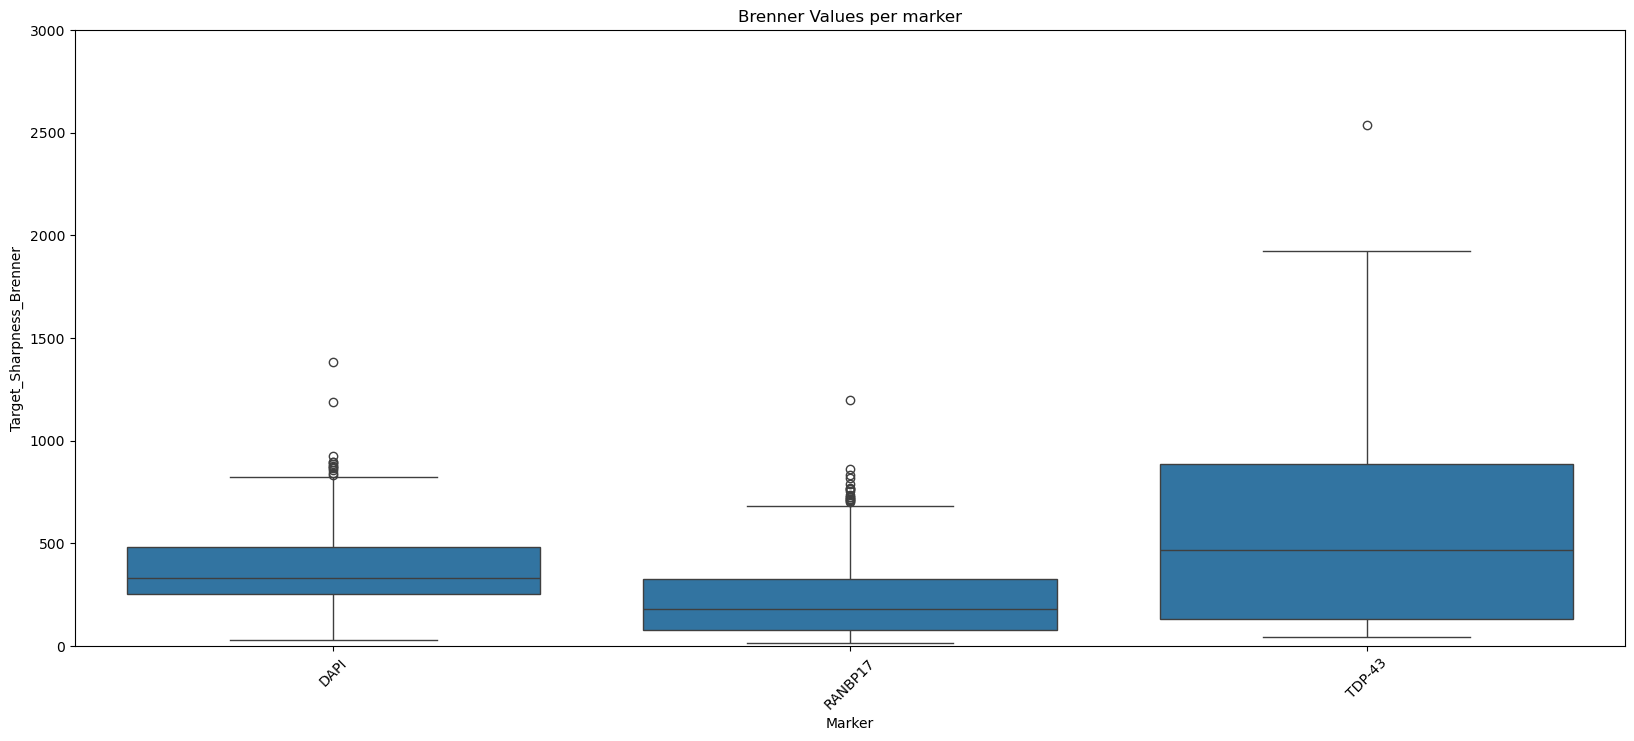

In [106]:
import seaborn as sns

# Plotting
plt.figure(figsize=(20,8))
sns.boxplot(x='Marker', y='Target_Sharpness_Brenner', data=df)
plt.xticks(rotation=45)
plt.title('Brenner Values per marker')
plt.ylim(0, 3000)
plt.show()

In [107]:
stats = df.groupby("Marker")["Target_Sharpness_Brenner"].describe()
stats

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
DAPI,686.0,377.016305,172.846386,28.434873,253.236302,331.726843,481.733673,1383.770239
RANBP17,686.0,228.041707,181.607495,13.128191,79.227374,181.710885,326.612682,1199.181505
TDP-43,686.0,561.045435,456.576878,41.421190,132.928989,466.721052,885.149269,2534.605536


In [108]:
df.groupby(['Marker','Condition','CellLine','Batch_Rep']).count()

Path  RootFolder  Rep  Batch  \
Marker  Condition   CellLine Batch_Rep                                   
DAPI    both_kd     iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        control_179 iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        control_180 iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        ranbp17_kd  iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        tardp_kd    iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        untreated   iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
                             batch1/rep3    49          49   49     49   
                             batch1/rep4    49          49   49     49   
RANBP17 both_kd     iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        control_179 iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        control_180 iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        ranbp17_kd  iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        tardp_kd    iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        untreated   iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
                             batch1/rep3    49          49   49     49   
                             batch1/rep4    49          49   49     49   
TDP-43  both_kd     iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        control_179 iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        control_180 iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        ranbp17_kd  iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        tardp_kd    iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
        untreated   iW11     batch1/rep1    49          49   49     49   
                             batch1/rep2    49          49   49     49   
                             batch1/rep3    49          49   49     49   
                             batch1/rep4    49          49   49     49   

                                          Target_Sharpness_Brenner  
Marker  Condition   CellLine Batch_Rep                              
DAPI    both_kd     iW11     batch1/rep1                        49  
                             batch1/rep2                        49  
        control_179 iW11     batch1/rep1                        49  
                             batch1/rep2                        49  
        control_180 iW11     batch1/rep1                        49  
                             batch1/rep2                        49  
        ranbp17_kd  iW11     batch1/rep1                        49  
                             batch1/rep2                        49  
        tardp_kd    iW11     batch1/rep1                        49  
                          

# Create Brenner reports

Run this block if you want to generate Brenner reports

In [109]:
if CREATE_REPORT:
    output_folder = f"{preprocessing_path}/brenner_reports{PROC_DATASET_NAME}_{datetime.now().strftime('%Y-%m-%d')}"
    print('output_folder is', output_folder)
    generate_marker_reports(df, all_markers, output_folder, percentiles_to_describe, percentile_ranges_for_reports, max_samples=3)

# We start here...

In [110]:
SAVE_THRESHOLDs = True # once we finish the thrsholds we can save them

# ------- Marker -------------
marker = 'DAPI' # marker to plot
# Options:
# ['DAPI',  'TDP-43', 'RANBP17']]

# ------- Intensity ----------
###### MARKERS ######
lower_bound = 0.5 # intensity lower bound value (under this will "black out" pixels)
upper_bound = 99.9 # intensity upper bound value (will "sterngthen" pixels to maximum)

######  DAPI  ######

dapi_lower_bound = 0.5
dapi_upper_bound = 99.75


max_samples = 20 # maximum sites to plot

In [111]:
# precentiles thresholds to be updated
thresholds = {
    'DAPI': (0, 100), # V, INTENSITY (0.5, 99.75)
    'RANBP17': (0, 100), # V INTENSITY (0.5, 99.9)
    'TDP-43': (0, 100) # V
}



# Examine Brenners and set the threshold in the next block (option 2)

1. Examine Brenners (write the thresholds in the next block)

/tmp/ipykernel_1206709/2783407255.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_marker["brenner_percentile"] = (
Cropping image to fit


Showing images between %50 - 60
Number of DAPI images in threshold 331.7268434546614 (50%) (and 371.22369351302336 (60%)): 69


0
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/untreated/rep2/DAPI/r05c18f39-ch2t1.tiff
Brenner percentile: 50.87463556851311%
Brenner: 1823.996
Img shape: (1024, 1024)


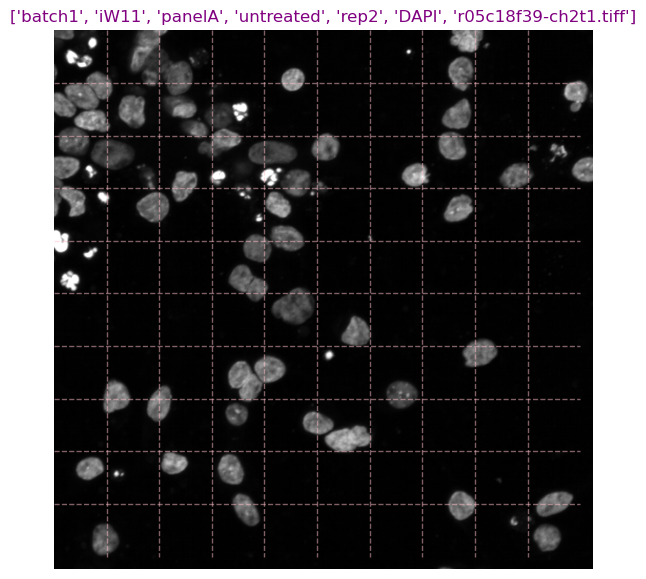

Cropping image to fit


----------------------------------------------------------------------------------------------------
1
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/control_180/rep2/DAPI/r05c10f04-ch2t1.tiff
Brenner percentile: 59.62099125364432%
Brenner: 2328.172
Img shape: (1024, 1024)


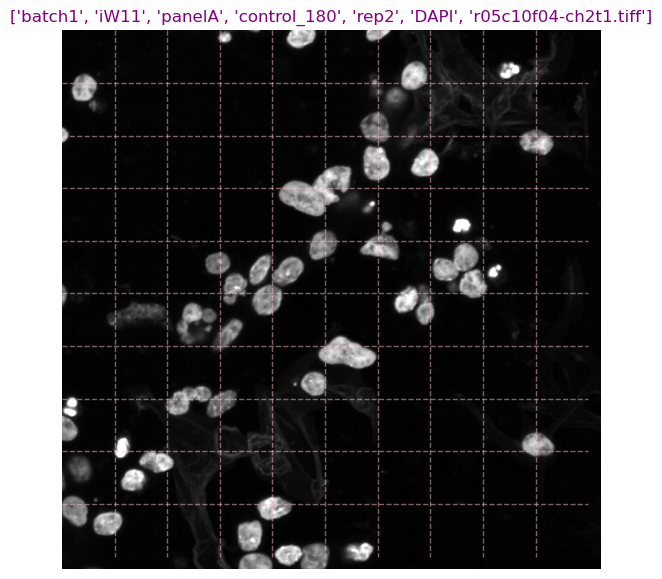

Cropping image to fit


----------------------------------------------------------------------------------------------------
2
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/control_180/rep1/DAPI/r04c10f02-ch2t1.tiff
Brenner percentile: 52.623906705539355%
Brenner: 2031.435
Img shape: (1024, 1024)


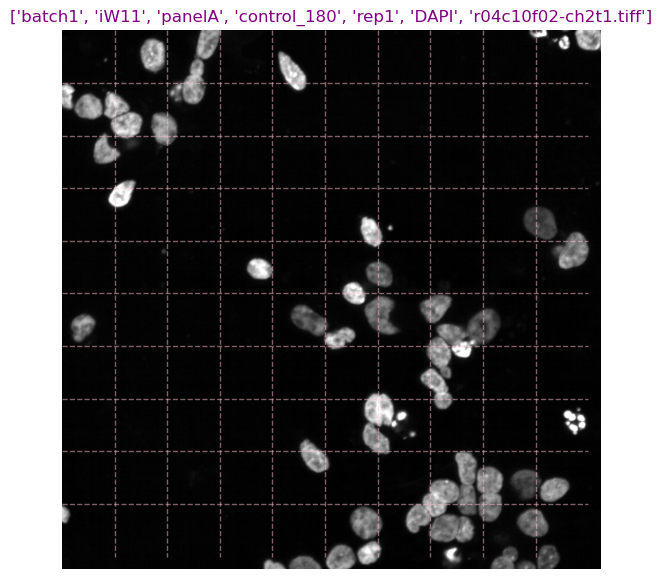

Cropping image to fit


----------------------------------------------------------------------------------------------------
3
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/control_180/rep2/DAPI/r05c10f31-ch2t1.tiff
Brenner percentile: 56.268221574344025%
Brenner: 1963.243
Img shape: (1024, 1024)


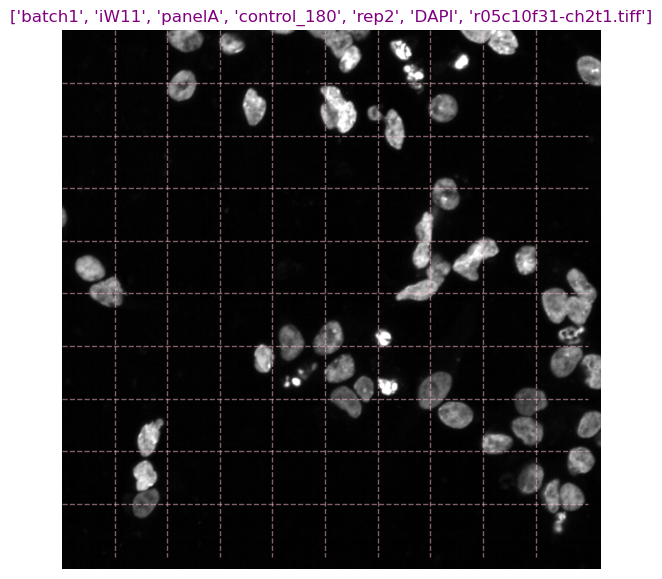

Cropping image to fit


----------------------------------------------------------------------------------------------------
4
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/untreated/rep3/DAPI/r04c19f31-ch2t1.tiff
Brenner percentile: 57.87172011661808%
Brenner: 1389.971
Img shape: (1024, 1024)


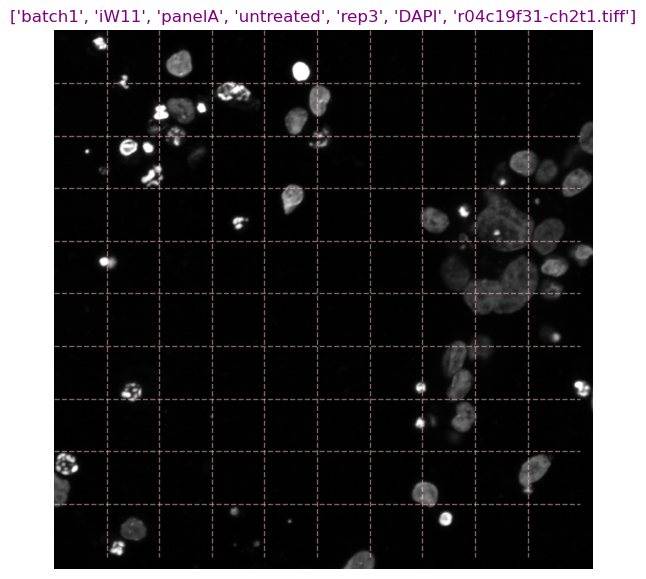

Cropping image to fit


----------------------------------------------------------------------------------------------------
5
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/tardp_kd/rep1/DAPI/r02c04f25-ch2t1.tiff
Brenner percentile: 53.93586005830904%
Brenner: 2124.811
Img shape: (1024, 1024)


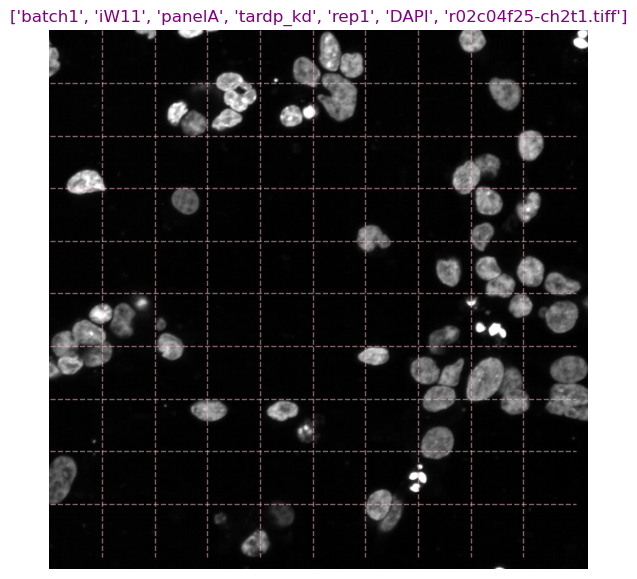

Cropping image to fit


----------------------------------------------------------------------------------------------------
6
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/control_180/rep2/DAPI/r05c10f13-ch2t1.tiff
Brenner percentile: 59.329446064139944%
Brenner: 2040.0
Img shape: (1024, 1024)


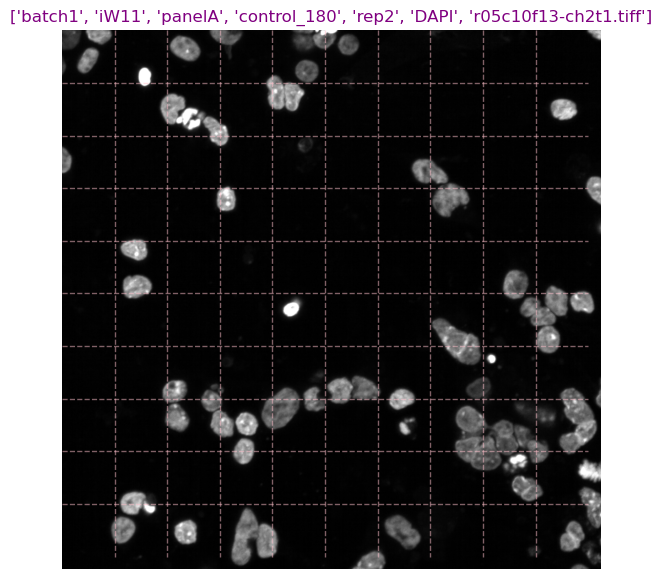

Cropping image to fit


----------------------------------------------------------------------------------------------------
7
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/tardp_kd/rep2/DAPI/r03c04f16-ch2t1.tiff
Brenner percentile: 53.64431486880466%
Brenner: 1060.41
Img shape: (1024, 1024)


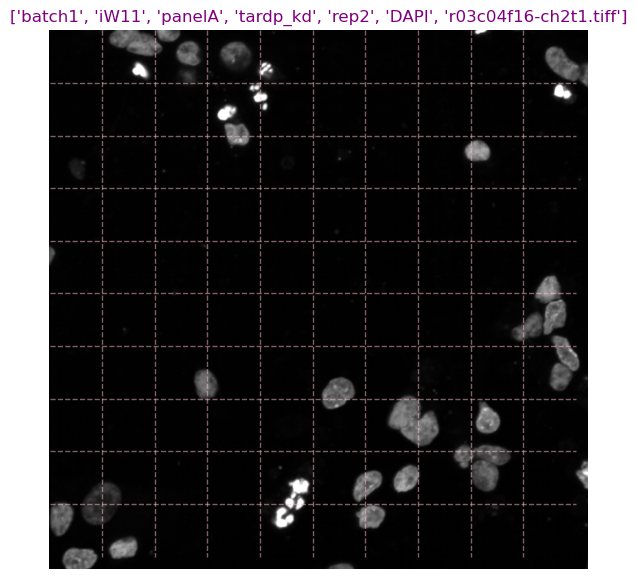

Cropping image to fit


----------------------------------------------------------------------------------------------------
8
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/tardp_kd/rep1/DAPI/r02c04f18-ch2t1.tiff
Brenner percentile: 54.518950437317784%
Brenner: 1997.151
Img shape: (1024, 1024)


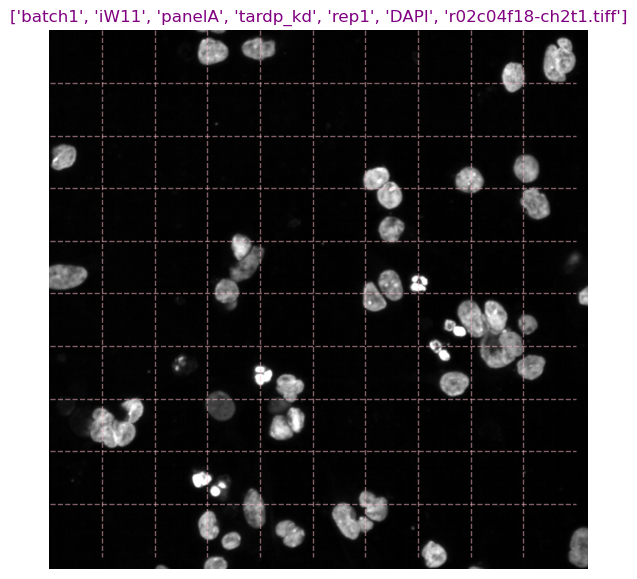

Cropping image to fit


----------------------------------------------------------------------------------------------------
9
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/both_kd/rep1/DAPI/r02c16f29-ch2t1.tiff
Brenner percentile: 55.24781341107872%
Brenner: 2010.31
Img shape: (1024, 1024)


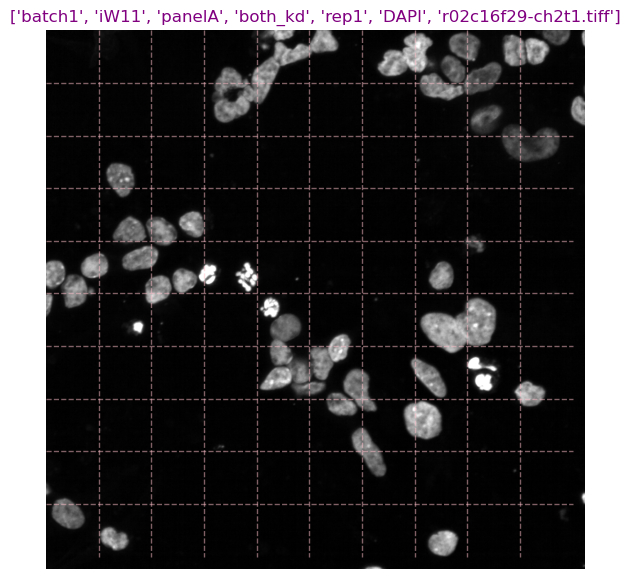

Cropping image to fit


----------------------------------------------------------------------------------------------------
10
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/ranbp17_kd/rep1/DAPI/r04c04f04-ch2t1.tiff
Brenner percentile: 59.037900874635575%
Brenner: 1656.567
Img shape: (1024, 1024)


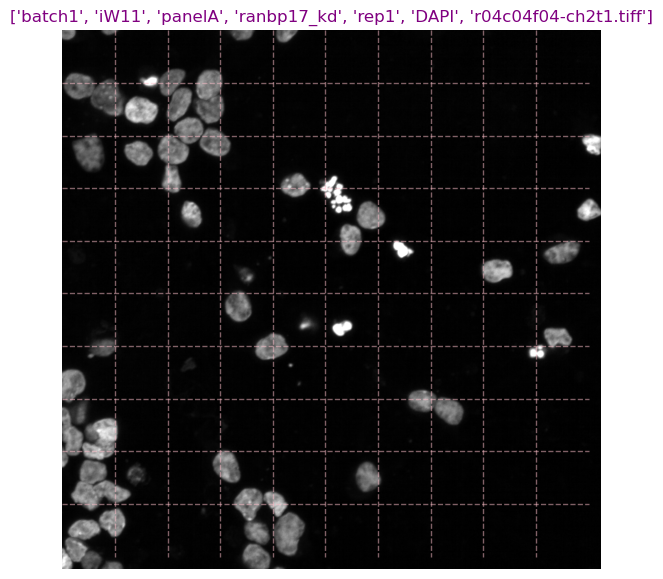

Cropping image to fit


----------------------------------------------------------------------------------------------------
11
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/tardp_kd/rep1/DAPI/r02c04f19-ch2t1.tiff
Brenner percentile: 54.22740524781341%
Brenner: 1348.745
Img shape: (1024, 1024)


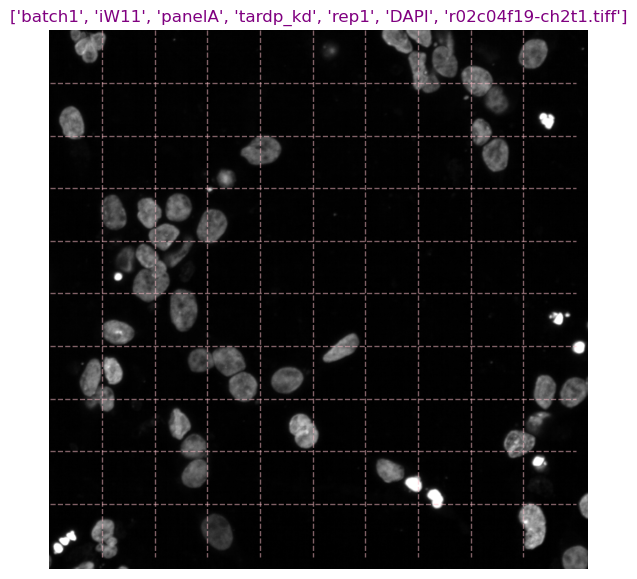

Cropping image to fit


----------------------------------------------------------------------------------------------------
12
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/control_180/rep2/DAPI/r05c10f15-ch2t1.tiff
Brenner percentile: 53.06122448979592%
Brenner: 1860.568
Img shape: (1024, 1024)


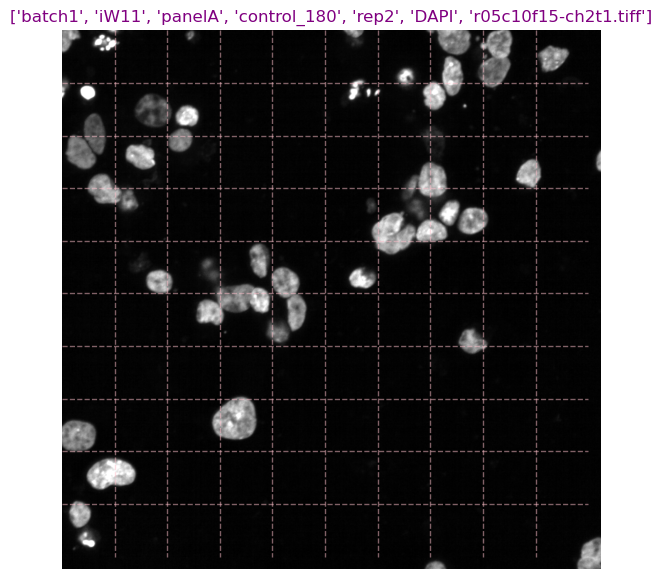

Cropping image to fit


----------------------------------------------------------------------------------------------------
13
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/tardp_kd/rep2/DAPI/r03c04f29-ch2t1.tiff
Brenner percentile: 52.1865889212828%
Brenner: 1764.782
Img shape: (1024, 1024)


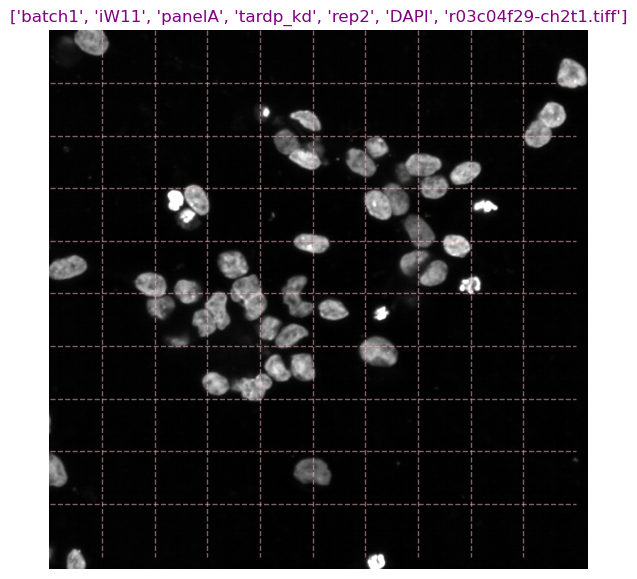

Cropping image to fit


----------------------------------------------------------------------------------------------------
14
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/control_180/rep1/DAPI/r04c10f28-ch2t1.tiff
Brenner percentile: 56.99708454810496%
Brenner: 2069.907
Img shape: (1024, 1024)


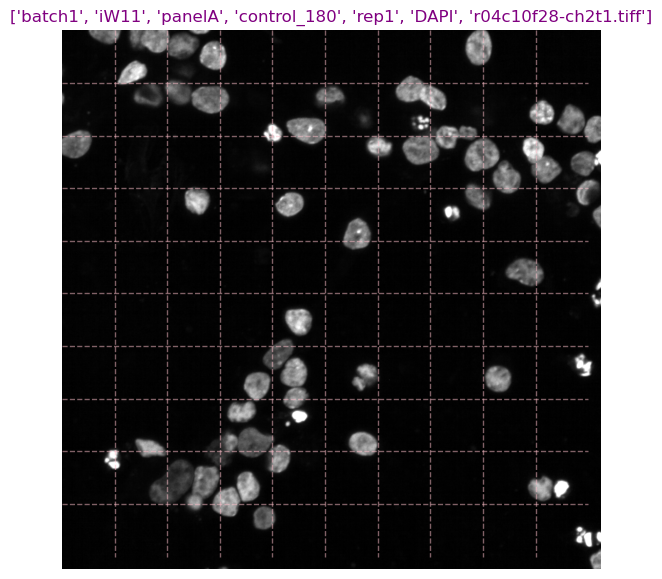

Cropping image to fit


----------------------------------------------------------------------------------------------------
15
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/untreated/rep2/DAPI/r05c18f44-ch2t1.tiff
Brenner percentile: 51.16618075801749%
Brenner: 1736.086
Img shape: (1024, 1024)


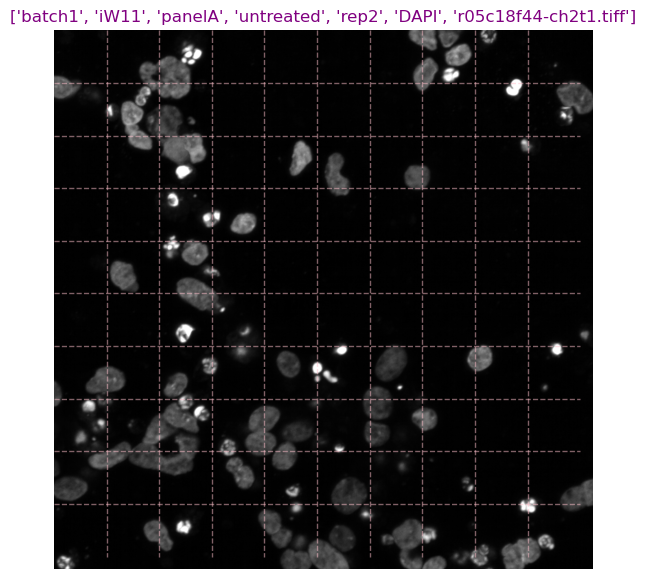

Cropping image to fit


----------------------------------------------------------------------------------------------------
16
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/tardp_kd/rep2/DAPI/r03c04f03-ch2t1.tiff
Brenner percentile: 52.91545189504373%
Brenner: 1471.454
Img shape: (1024, 1024)


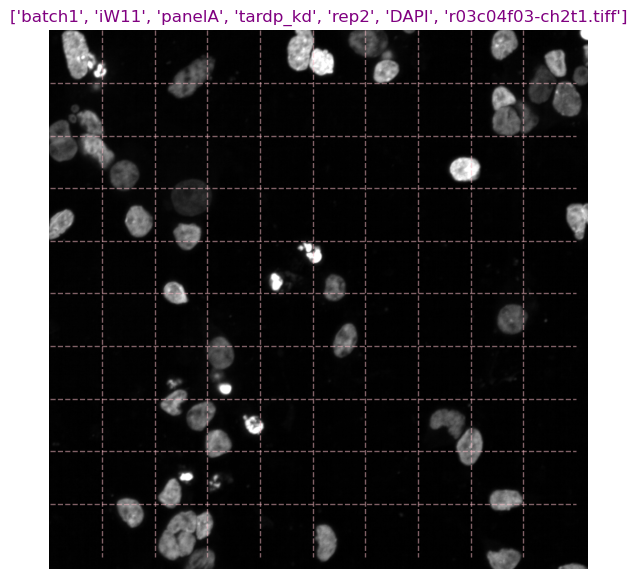

Cropping image to fit


----------------------------------------------------------------------------------------------------
17
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/tardp_kd/rep2/DAPI/r03c04f07-ch2t1.tiff
Brenner percentile: 56.12244897959183%
Brenner: 1079.271
Img shape: (1024, 1024)


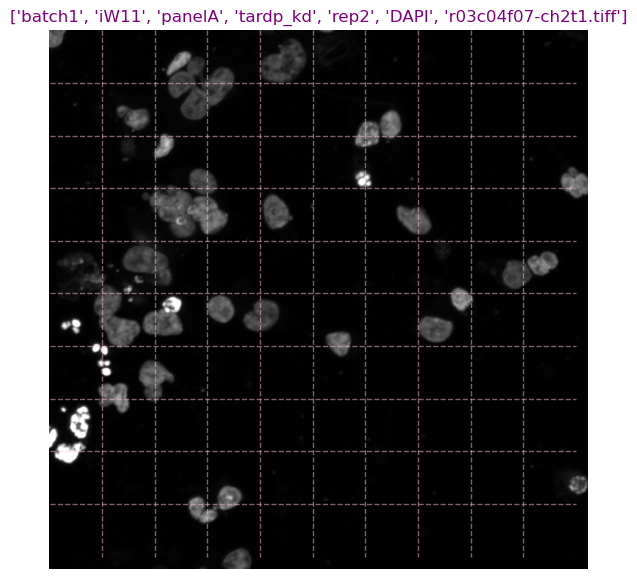

Cropping image to fit


----------------------------------------------------------------------------------------------------
18
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/tardp_kd/rep1/DAPI/r02c04f31-ch2t1.tiff
Brenner percentile: 57.288629737609334%
Brenner: 2226.241
Img shape: (1024, 1024)


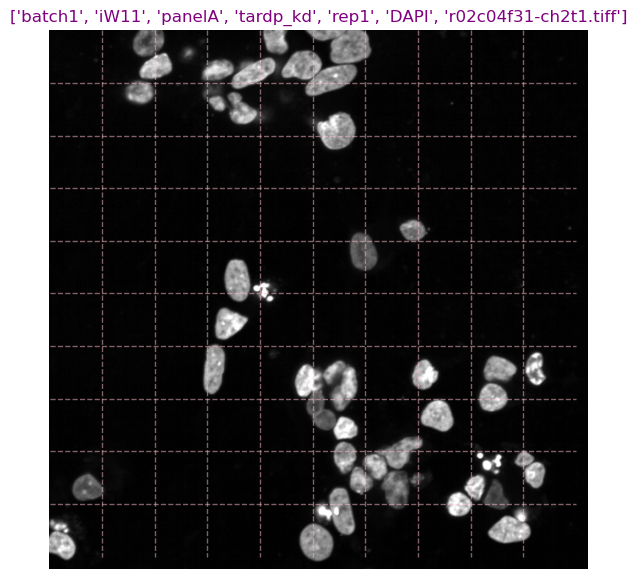

Cropping image to fit


----------------------------------------------------------------------------------------------------
19
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch1/iW11/panelA/ranbp17_kd/rep2/DAPI/r05c04f43-ch2t1.tiff
Brenner percentile: 59.7667638483965%
Brenner: 2087.788
Img shape: (1024, 1024)


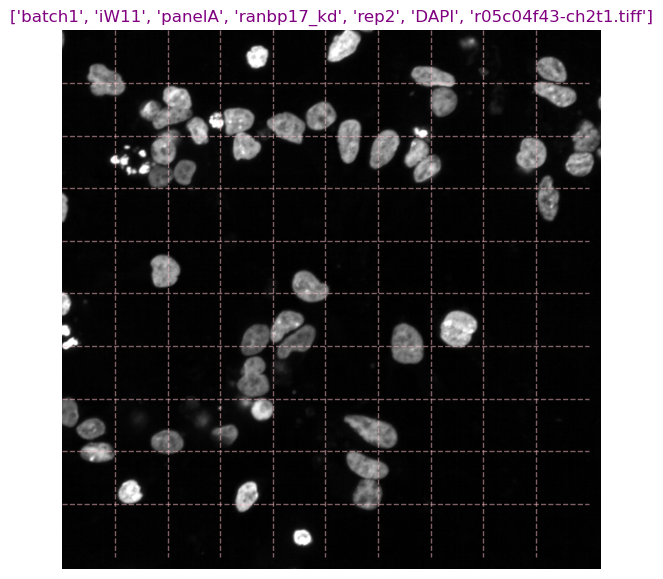

----------------------------------------------------------------------------------------------------
20
Stopping at 20. There are 69 images in total


In [112]:
#################### SAFE ZONE TO CHANGE ###############
per_min = 50# show images from this percentile and above
per_max = 60 # show images up to this percentile
batch=None
rep=None
cell_line=None

###################### END OF SAFE ZONE ###################


df_marker = df.loc[df['Marker'] == marker]
marker_max_value = df_marker[metric_name].max()

percentiles = df_marker[metric_name].describe(percentiles=percentiles_to_describe)

print(f'Showing images between %{per_min} - {per_max}')
threshold = percentiles[f'{per_min}%']
threshold_second = percentiles[f'{per_max}%']

df_marker["brenner_percentile"] = (
    df_marker[metric_name].rank(pct=True) * 100
)

c = (df_marker[metric_name]>=threshold) & (df_marker[metric_name]<=threshold_second) 

# threshold
df_marker_filtered = df_marker[c]
# shuffle
df_marker_filtered = df_marker_filtered.sample(frac=1, random_state=1)
# df_marker_filtered.index = range(len(df_marker_filtered))

print(f"Number of {marker} images in threshold {threshold} ({per_min}%) (and {threshold_second} ({per_max}%)): {len(df_marker_filtered)}")
# print("\n")
# print(df_marker_filtered['CellLine'].value_counts().to_string())
# print("\n")
# print(df_marker_filtered['Condition'].value_counts().to_string())
print("\n")
show_images(df_marker_filtered, marker_name=marker, max_samples=max_samples, lower_bound=lower_bound, upper_bound=upper_bound, dapi_lower_bound=dapi_lower_bound, dapi_upper_bound=dapi_upper_bound)

2. Setting Brenners in the csv

# Save thresholds

In [113]:
# print mappings_filepath
mappings_filepath

'/home/projects/hornsteinlab/giliwo/NOVA/manuscript/markers_focus_boundries/markers_focus_boundries_RANBP17_exp.csv'

In [114]:
# print thresholds to be saved
thresholds


{'DAPI': (0, 100), 'RANBP17': (0, 100), 'TDP-43': (0, 100)}

In [115]:
mappings = update_all_mappings(mappings, thresholds, df)
print(mappings)

         Lower_bound  Upper_bound
DAPI           28.43      1383.77
TDP-43         41.42      2534.61
RANBP17        13.13      1199.18


In [116]:
if SAVE_THRESHOLDs:
    # update the mappings

    mappings.to_csv(mappings_filepath)

    print("Saved mappings to:", mappings_filepath)
    print("mappings saved:")
    mappings

Saved mappings to: /home/projects/hornsteinlab/giliwo/NOVA/manuscript/markers_focus_boundries/markers_focus_boundries_RANBP17_exp.csv
mappings saved:
